

## Module Overview: Regression & Car Price Prediction

This module covers the end-to-end process of building, evaluating, and improving a **Linear Regression** model to predict car prices using historical dataset features.

### Key Objectives & Workflow:

* **Exploratory Data Analysis (EDA) & Data Preparation:** Inspect target distribution (applying logarithmic transformations to handle right-skewed price data) and handle missing values through zero/mean imputation.
* **Validation Strategy:** Set up a robust train/validation/test split framework ($60\% / 20\% / 20\%$) to prevent data leakage and evaluate model generalization.
* **Linear Regression Mechanics:** Implement Linear Regression from scratch using vector form and the normal equation $(X^T X)^{-1} X^T y$.
* **Model Evaluation:** Assess predictions using **Root Mean Squared Error (RMSE)** on the validation set to establish baseline performance.
* **Feature Engineering & Categorical Variables:** Enhance features through categorical encoding (one-hot encoding) and domain-specific transformations to boost accuracy.
* **Regularization & Hyperparameter Tuning:** Apply Ridge ($L2$) regularization to control weight expansion, prevent multicollinearity, and optimize hyperparameters on validation performance.

In [1]:
import pandas as pd
import numpy as np

**Data Preparation**

In [5]:
# Get the data

data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
!wget $data

--2026-10-01 20:20:38--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.2’

data.csv.2          100%[===================>]   1.41M  --.-KB/s    in 0.03s   

2026-10-01 20:20:38 (51.5 MB/s) - ‘data.csv.2’ saved [1475504/1475504]



In [2]:
# Load the data

df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:

# Clean the column names

df.columns = df.columns.str.lower().str.replace(' ', '_')

In [4]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [5]:
# find string columns

strings = df.dtypes[df.dtypes == 'string'].index.tolist()
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [6]:
# Clean the string columns
for column in strings:
    df[column] = df[column].str.lower().str.replace(' ', '_')

In [7]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


**Exploratory Data Analysis**

In [8]:
# Explore the data
for column in df.columns:
    print(column)
    print(df[column].unique()[:5]) 
    print(df[column].nunique())

    print('-------------------------')

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48
-------------------------
model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914
-------------------------
year
[2011 2012 2013 1992 1993]
28
-------------------------
engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10
-------------------------
engine_hp
[335. 300. 230. 320. 172.]
356
-------------------------
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
-------------------------
transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5
-------------------------
driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4
-------

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Text(0.5, 1.0, 'Distribution of MSRP')

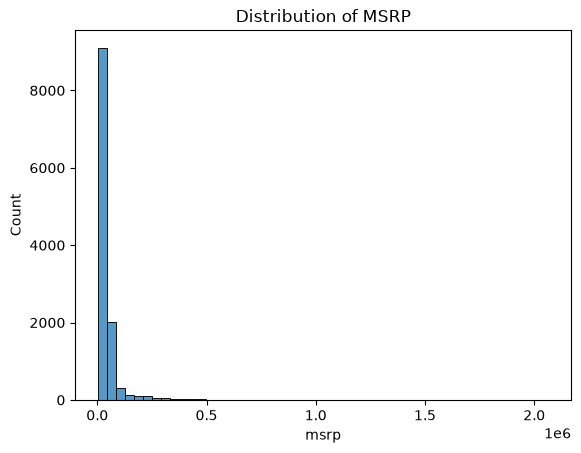

In [10]:
# Explore the target variable

sns.histplot(data=df.msrp, bins=50)
plt.title('Distribution of MSRP')

<Axes: xlabel='msrp', ylabel='Count'>

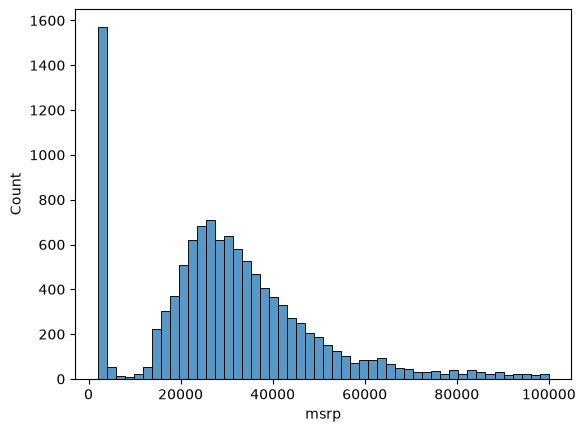

In [11]:
sns.histplot(data=df.msrp[df.msrp < 100000], bins=50)

Text(0.5, 1.0, 'Distribution of log(MSRP)')

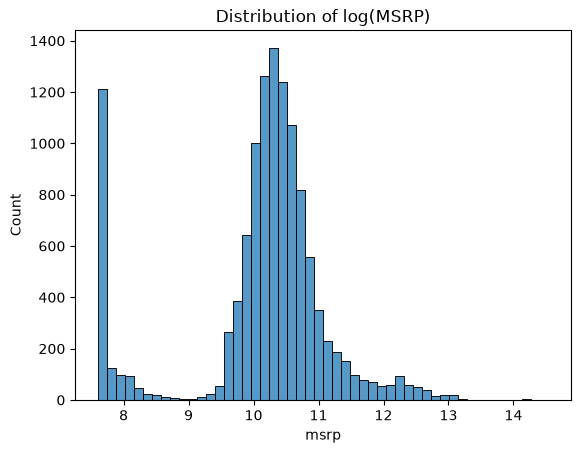

In [12]:
# Log-transform the price variable
price_log = np.log1p(df.msrp)
sns.histplot(data=price_log, bins=50)
plt.title('Distribution of log(MSRP)')

In [13]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [14]:


n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# randomly shuffle the indices of the data
index = np.arange(n)
np.random.seed(2)
np.random.shuffle(index)

# Split the data into train, validation, and test sets
df_train = df.iloc[index[:n_train]]
df_val = df.iloc[index[n_train:n_train+n_val]]
df_test = df.iloc[index[n_train+n_val:]]



In [15]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [16]:
# Reset the index of the dataframes

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [17]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [18]:
#log-transform the target variable 
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

#delete the target variable from the dataframes
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

**Baseline Model**

In [19]:
# Train a baseline linear regression model 

def train_linear_regression(X, y):
    # Add a bias column to the data
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    
    # Calculate the weights 
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    
    return w[0], w[1:]  # Return bias and weights separately

In [20]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [21]:
# Select the features for the model
base =['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

#missing values are filled with 0
X_train = df_train[base].fillna(0).values

#train the model
w0, w = train_linear_regression(X_train, y_train)



In [22]:
# Predict the target values
y_pred_train = w0 + X_train @ w

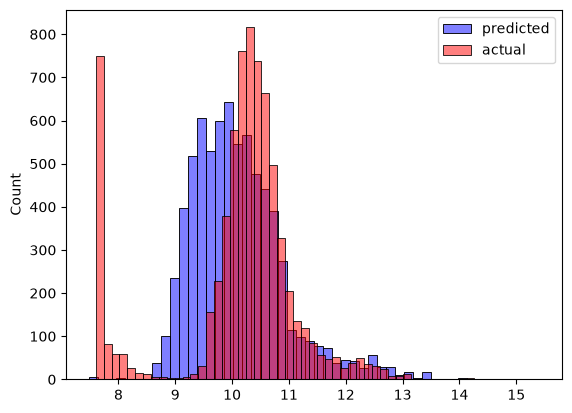

In [23]:
# Visualize the predicted and actual values
sns.histplot(y_pred_train, color='blue', alpha=0.5, label='predicted',bins=50)
sns.histplot(y_train, color='red', alpha=0.5, label='actual',bins=50)
plt.legend()

**Root Mean Squared Error (RMSE)**

In [24]:
# Calculate the RMSE for the training set
def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).mean())

rmse_train = rmse(y_train, y_pred_train)
print(rmse_train)

0.7554192603920132


In [25]:
#
def prepare_X(df):
    X = df[base].fillna(0).values
    return X

In [26]:
#validate the model on the validation set
X_val= prepare_X(df_val)
y_pred_val = w0 + X_val @ w

#rmse for the validation set
rmse_val = rmse(y_val, y_pred_val)
print(rmse_val)

0.761653099130156


**Feature engineering**

In [27]:
def prepare_X(df):
    #create a copy of the dataframe to avoid modifying the original dataframe
    df = df.copy()
    
    #add a new feature 'age' to the dataframe
    df['age'] = 2017 - df['year']
    features = base + ['age']

    X = df[features].fillna(0).values
    return X

In [28]:

X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val @ w 
rmse_val = rmse(y_val, y_pred_val)
print(rmse_val)

0.5172055461058299


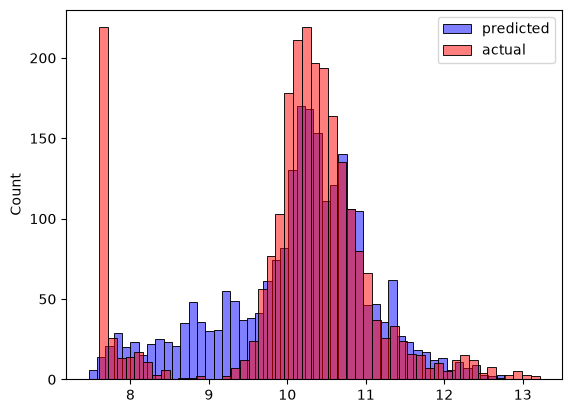

In [29]:
sns.histplot(y_pred_val, color='blue', alpha=0.5, label='predicted',bins=50)
sns.histplot(y_val, color='red', alpha=0.5, label='actual',bins=50)
plt.legend()

**Categorical variables**

In [30]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df['year']
    features.append('age')
    
#add new features for the number of doors
    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%s' % v)

    X = df[features].fillna(0).values
    return X


In [31]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val @ w 
rmse_val = rmse(y_val, y_pred_val)
print(rmse_val)

0.515799564150169


In [32]:
#create a list of categorical variables
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

#create a dictionary of the top 5 categories for each categorical variable
categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [33]:
#categorical variables are added to the model

def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df['year']
    features.append('age')

    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%s' % v)

        
    #Othercategorical variables are added to the model
    for c,values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype(int)
            features.append('%s_%s' % (c, v))

    X = df[features].fillna(0).values
    return X

In [34]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val @ w 
rmse_val = rmse(y_val, y_pred_val)
print(rmse_val)

18.233065519897817


**Regularization**

In [35]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [ ]:
# Train a linear regression model 

def train_linear_regression_reg(X, y, r=0.001):
    # Add a bias column to the data
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    
    XTX = X.T @ X 
    XTX = XTX + r * np.eye(XTX.shape[0])

    # Calculate the weights 
    w = np.linalg.inv(XTX) @ X.T @ y
    
    return w[0], w[1:]  # Return bias and weights separately

In [44]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)  

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val @ w
rmse_val = rmse(y_val, y_pred_val)
print(rmse_val)

0.456521990159498


**Tuning the model**

In [ ]:
#find the best regularization parameter r using the validation set

for r in [0, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred_val = w0 + X_val @ w
    rmse_val = rmse(y_val, y_pred_val)

    print(r,w0,rmse_val) 



0 1490771050477478.8 18.233065519897817
1e-05 3.3018558489965324 0.456517033264953
0.0001 6.336852827878064 0.4565170658328043
0.001 6.285637034753571 0.4565175085263347
0.01 6.276608807851224 0.456521990159498
0.1 6.191208619220593 0.45656927629982347
1 5.63489666798207 0.4572204317993079
10 4.283980108964413 0.47014569320989463


In [50]:
#train the model with the best regularization parameter r=0.00001
r = 0.00001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred_val = w0 + X_val @ w
rmse_val = rmse(y_val, y_pred_val)
print(rmse_val)


0.456517033264953


**Using the model**

In [ ]:

#train the model on the full training set
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

X_full_train = prepare_X(df_full_train)

y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [ ]:
#test the model
X_test = prepare_X(df_test)
y_pred_test= w0 + X_test.dot(w)
rmse_test = rmse(y_test, y_pred_test)
print(rmse_test)

0.45222798582840673


In [54]:
#make a prediction for a single car from the test set
car = df_test.iloc[20].to_dict()

df_small = pd.DataFrame([car])
X_small = prepare_X(df_small)


y_pred_small = w0 + X_small.dot(w)
y_pred_small = y_pred_small[0]
print(y_pred_small)

10.442860583066878


In [59]:
#the predicted price of the car
print(np.expm1(y_pred_small))


34297.62630951904


In [60]:
#the actual price of the car
print(np.expm1(y_test[20]))

35000.00000000001
